In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import shuffle

from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.inspection import permutation_importance
import shap

C:\Users\2001z\Downloads\4. félév\Data Science project in Business\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [ ]:
df = pd.read_csv('data/software_defect_prediction_dataset.csv')

In [4]:
display(df.head())

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
0,910,12,7,79,0.59,539,19,4,23,7,...,70,1,54,27,0.06,3,20,31,21,1
1,3822,9,197,72,0.30,584,8,8,126,153,...,180,5,73,23,0.39,9,154,38,29,1
2,3142,20,99,92,0.11,593,0,6,272,177,...,152,5,9,31,0.08,7,425,22,6,1
3,516,39,52,79,0.18,81,12,14,16,0,...,159,9,23,12,0.44,2,339,24,12,1
4,4476,27,162,75,0.21,918,14,1,164,109,...,169,2,84,9,0.41,3,111,19,2,1


In [5]:
print(f"Dataset shape: {df.shape}")

Dataset shape: (60000, 23)


In [6]:
display(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   lines_of_code               60000 non-null  int64  
 1   cyclomatic_complexity       60000 non-null  int64  
 2   num_functions               60000 non-null  int64  
 3   num_classes                 60000 non-null  int64  
 4   comment_density             60000 non-null  float64
 5   code_churn                  60000 non-null  int64  
 6   developer_experience_years  60000 non-null  int64  
 7   num_developers              60000 non-null  int64  
 8   commit_frequency            60000 non-null  int64  
 9   bug_fix_commits             60000 non-null  int64  
 10  past_defects                60000 non-null  int64  
 11  test_coverage               60000 non-null  float64
 12  duplication_percentage      60000 non-null  float64
 13  avg_function_length         60000 non-null

None

In [7]:
display(df.describe())

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
count,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.00000,60000.000000,60000.000000
mean,2530.351467,25.085650,99.900683,49.371517,0.300259,500.247800,9.465667,7.492883,150.296117,99.262667,...,102.109167,4.506767,49.991167,25.099967,0.499512,9.467117,248.720767,24.44745,14.473250,0.970383
std,1428.229382,14.112331,57.367154,28.827881,0.173254,288.724453,5.768672,4.032777,86.375771,57.774507,...,56.279245,2.866878,28.721025,14.139460,0.289559,5.746556,144.011768,14.46083,8.663821,0.169529
min,50.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,...,5.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1299.000000,13.000000,50.000000,24.000000,0.150000,251.000000,4.000000,4.000000,76.000000,49.000000,...,53.000000,2.000000,25.000000,13.000000,0.250000,4.000000,124.000000,12.00000,7.000000,1.000000
50%,2534.000000,25.000000,99.000000,49.000000,0.300000,501.000000,9.000000,7.000000,151.000000,99.000000,...,102.000000,5.000000,50.000000,25.000000,0.500000,9.000000,249.000000,24.00000,14.000000,1.000000
75%,3763.000000,37.000000,149.000000,74.000000,0.450000,750.000000,14.000000,11.000000,225.000000,149.000000,...,151.000000,7.000000,75.000000,37.000000,0.750000,14.000000,373.000000,37.00000,22.000000,1.000000
max,4999.000000,49.000000,199.000000,99.000000,0.600000,999.000000,19.000000,14.000000,299.000000,199.000000,...,199.000000,9.000000,99.000000,49.000000,1.000000,19.000000,499.000000,49.00000,29.000000,1.000000


In [8]:
missing_values = df.isnull().sum()
print("Missing values per column:",sum(missing_values) , missing_values[missing_values > 0])

Missing values per column: 0 Series([], dtype: int64)


In [9]:
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


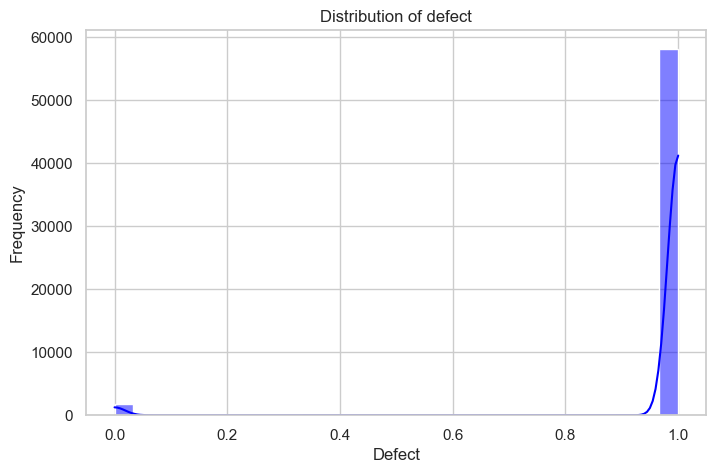

In [10]:
#distribution of the target variable
plt.figure(figsize=(8, 5))
sns.histplot(df['defect'], bins=30, kde=True, color='blue')
plt.title('Distribution of defect')
plt.xlabel('Defect')
plt.ylabel('Frequency')
plt.show()

In [11]:
print((df['defect'] == 0).sum())
print((df['defect'] == 1).sum())

1777
58223


In [12]:
X = df.drop(columns=['defect'])
y = df['defect']

In [13]:
test_idx = y[y == 0].sample(600, random_state=42).index.append(
            y[y == 1].sample(600, random_state=42).index
           )

train_idx = y.index.difference(test_idx)

X_train, y_train = X.loc[train_idx], y.loc[train_idx]
X_test, y_test = X.loc[test_idx], y.loc[test_idx]

X_train, y_train = shuffle(X_train, y_train, random_state=42)
X_test, y_test = shuffle(X_test, y_test, random_state=42)

In [14]:
#X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.99,random_state=42, stratify=y)

print(len(X_test))
print(len(X_train))

print((y_test == 0).sum())
print((y_test == 1).sum())

1200
58800
600
600


In [15]:
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(len(X_train))
print(len(y_train))

print(len(X_train_sm))
print(len(y_train_sm))


58800
58800
115246
115246


In [16]:
df_train_sm = pd.concat(
    [pd.DataFrame(X_train_sm, columns=X.columns),
     pd.DataFrame(y_train_sm, columns=["defect"])],
    axis=1
)
df_train_sm

,lines_of_code,cyclomatic_complexity,num_functions,num_classes,comment_density,code_churn,developer_experience_years,num_developers,commit_frequency,bug_fix_commits,...,avg_function_length,depth_of_inheritance,response_for_class,coupling_between_objects,lack_of_cohesion,build_failures,static_analysis_warnings,security_vulnerabilities,performance_issues,defect
0,4107,36,158,29,0.400000,839,14,8,80,110,...,68,9,50,18,0.230000,15,311,37,10,1
1,91,41,100,29,0.300000,335,19,6,275,143,...,16,7,13,49,0.270000,10,56,45,10,1
2,3218,11,58,97,0.210000,912,18,13,185,101,...,166,6,10,46,0.900000,0,157,10,16,1
3,1662,30,29,62,0.050000,521,16,8,112,195,...,147,6,82,19,0.190000,11,217,46,29,1
4,3800,7,24,65,0.580000,405,8,5,16,143,...,129,2,3,1,0.720000,0,262,43,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115241,4589,17,37,73,0.143340,599,14,8,283,113,...,31,2,78,31,0.091338,4,28,31,21,0
115242,1710,18,155,47,0.247711,713,17,8,206,33,...,86,1,54,6,0.740784,9,185,38,10,0
115243,2113,11,92,50,0.380304,627,18,11,235,143,...,96,2,77,27,0.129609,0,184,5,9,0
115244,2609,16,65,60,0.335473,730,12,13,26,128,...,110,0,5,33,0.417731,8,109,9,21,0


In [17]:
print((df_train_sm['defect'] == 0).sum())
print((df_train_sm['defect'] == 1).sum())

57623
57623


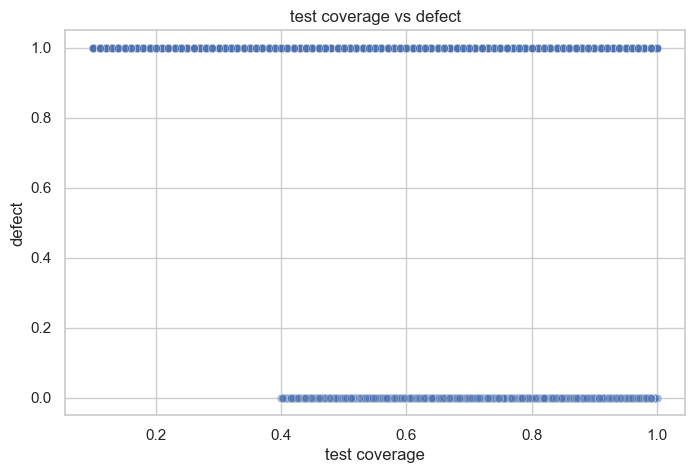

In [18]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_train_sm, x='test_coverage', y='defect', alpha=0.3)
plt.title('test coverage vs defect')
plt.xlabel('test coverage')
plt.ylabel('defect')
plt.show()

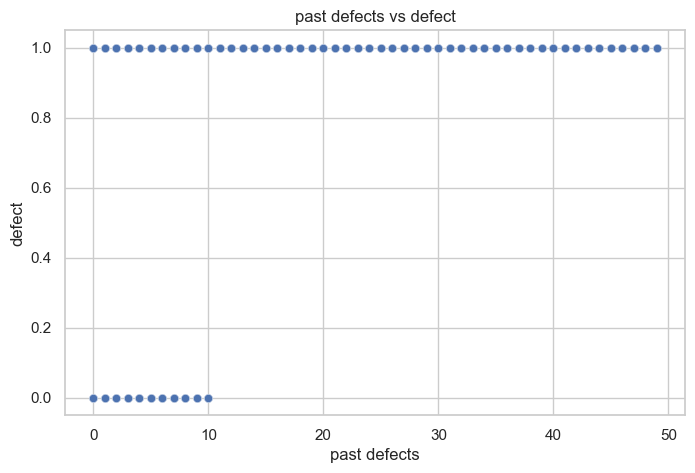

In [19]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_train_sm, x='past_defects', y='defect', alpha=0.3)
plt.title('past defects vs defect')
plt.xlabel('past defects')
plt.ylabel('defect')
plt.show()

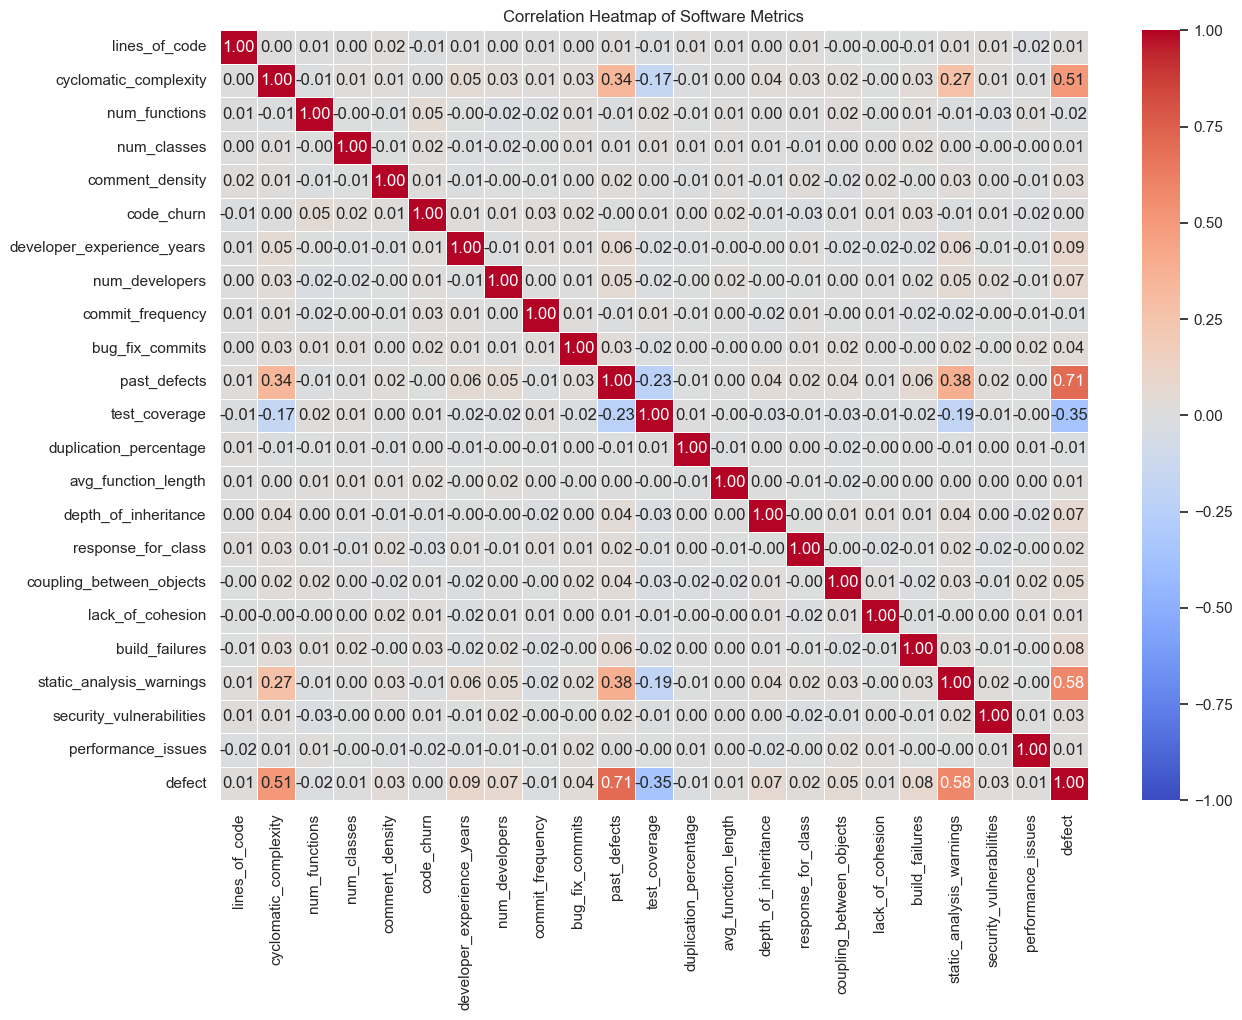

Correlation with defect:

defect                        1.000000
past_defects                  0.707946
static_analysis_warnings      0.580736
cyclomatic_complexity         0.506172
developer_experience_years    0.085999
build_failures                0.076088
num_developers                0.074979
depth_of_inheritance          0.069170
coupling_between_objects      0.050847
bug_fix_commits               0.040170
comment_density               0.032453
security_vulnerabilities      0.028947
response_for_class            0.016069
lines_of_code                 0.014407
performance_issues            0.008879
avg_function_length           0.008218
lack_of_cohesion              0.007886
num_classes                   0.006770
code_churn                    0.001545
commit_frequency             -0.008253
duplication_percentage       -0.009780
num_functions                -0.018913
test_coverage                -0.352543
Name: defect, dtype: float64


In [20]:
#only numerical columns
numerical_df = df_train_sm.select_dtypes(include=[np.number])

#correlation matrix
corr_matrix = numerical_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Correlation Heatmap of Software Metrics')
plt.show()

# Isolate the correlations specifically with the target variable
print("Correlation with defect:\n")
print(corr_matrix['defect'].sort_values(ascending=False))

# Model predictions

## Random Forest

In [21]:
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train_sm,y_train_sm)
rf_preds = rf.predict(X_test)

rf_cm = confusion_matrix(y_test, rf_preds)
print("Confusion Matrix:")
print(rf_cm)

Confusion Matrix:
[[573  27]
 [  0 600]]


In [22]:
print("Accuracy:", accuracy_score(y_test, rf_preds))
print("Precision:", precision_score(y_test, rf_preds))
print("Recall:", recall_score(y_test, rf_preds))
print("F1-score:", f1_score(y_test, rf_preds))

Accuracy: 0.9775
Precision: 0.9569377990430622
Recall: 1.0
F1-score: 0.9779951100244498


In [23]:
print(classification_report(y_test, rf_preds))

              precision    recall  f1-score   support

           0       1.00      0.95      0.98       600
           1       0.96      1.00      0.98       600

    accuracy                           0.98      1200
   macro avg       0.98      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200



## XGBoost

In [24]:
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_train_sm, y_train_sm)
xgb_preds = xgb.predict(X_test)
xgb_cm = confusion_matrix(y_test, xgb_preds)

print("Confusion Matrix:")
print(xgb_cm)

Confusion Matrix:
[[597   3]
 [  0 600]]


In [25]:
print("Accuracy:", accuracy_score(y_test, xgb_preds))
print("Precision:", precision_score(y_test, xgb_preds))
print("Recall:", recall_score(y_test, xgb_preds))
print("F1-score:", f1_score(y_test, xgb_preds))

Accuracy: 0.9975
Precision: 0.9950248756218906
Recall: 1.0
F1-score: 0.9975062344139651


In [26]:
print(classification_report(y_test, xgb_preds))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       600
           1       1.00      1.00      1.00       600

    accuracy                           1.00      1200
   macro avg       1.00      1.00      1.00      1200
weighted avg       1.00      1.00      1.00      1200



## SVM linear

In [27]:
svm_lin = SVC(kernel="linear", probability=True, random_state=42,max_iter=1000)

svm_lin.fit(X_train_sm, y_train_sm)
svm_lin_preds = svm_lin.predict(X_test)

svm_lin_cm = confusion_matrix(y_test, svm_lin_preds)

print("Confusion Matrix:")
print(svm_lin_cm)

Confusion Matrix:
[[307 293]
 [200 400]]


C:\Users\2001z\Downloads\4. félév\Data Science project in Business\venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [28]:
print("Accuracy:", accuracy_score(y_test, svm_lin_preds))
print("Precision:", precision_score(y_test, svm_lin_preds))
print("Recall:", recall_score(y_test, svm_lin_preds))
print("F1-score:", f1_score(y_test, svm_lin_preds))

Accuracy: 0.5891666666666666
Precision: 0.5772005772005772
Recall: 0.6666666666666666
F1-score: 0.6187161639597835


In [29]:
print(classification_report(y_test, svm_lin_preds))

              precision    recall  f1-score   support

           0       0.61      0.51      0.55       600
           1       0.58      0.67      0.62       600

    accuracy                           0.59      1200
   macro avg       0.59      0.59      0.59      1200
weighted avg       0.59      0.59      0.59      1200



## SVM rbf

In [30]:
svm_rbf = SVC(kernel="rbf", probability=True, random_state=42,max_iter=1000)

svm_rbf.fit(X_train_sm, y_train_sm)
svm_rbf_preds = svm_rbf.predict(X_test)

svm_rbf_cm = confusion_matrix(y_test, svm_rbf_preds)

print("Confusion Matrix:")
print(svm_rbf_cm)

C:\Users\2001z\Downloads\4. félév\Data Science project in Business\venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Confusion Matrix:
[[154 446]
 [ 99 501]]


In [31]:
print("Accuracy:", accuracy_score(y_test, svm_rbf_preds))
print("Precision:", precision_score(y_test, svm_rbf_preds))
print("Recall:", recall_score(y_test, svm_rbf_preds))
print("F1-score:", f1_score(y_test, svm_rbf_preds))

Accuracy: 0.5458333333333333
Precision: 0.529039070749736
Recall: 0.835
F1-score: 0.6477052359405301


In [32]:
print(classification_report(y_test, svm_rbf_preds))

              precision    recall  f1-score   support

           0       0.61      0.26      0.36       600
           1       0.53      0.83      0.65       600

    accuracy                           0.55      1200
   macro avg       0.57      0.55      0.50      1200
weighted avg       0.57      0.55      0.50      1200



## SVM sigmoid

In [33]:
svm_sig = SVC(kernel="sigmoid", probability=True, random_state=42,max_iter=1000)

svm_sig.fit(X_train_sm, y_train_sm)
svm_sig_preds = svm_sig.predict(X_test)

svm_sig_cm = confusion_matrix(y_test, svm_sig_preds)

print("Confusion Matrix:")
print(svm_sig_cm)

Confusion Matrix:
[[125 475]
 [131 469]]


C:\Users\2001z\Downloads\4. félév\Data Science project in Business\venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


In [34]:
print("Accuracy:", accuracy_score(y_test, svm_sig_preds))
print("Precision:", precision_score(y_test, svm_sig_preds))
print("Recall:", recall_score(y_test, svm_sig_preds))
print("F1-score:", f1_score(y_test, svm_sig_preds))

Accuracy: 0.495
Precision: 0.4968220338983051
Recall: 0.7816666666666666
F1-score: 0.6075129533678757


In [35]:
print(classification_report(y_test, svm_sig_preds))

              precision    recall  f1-score   support

           0       0.49      0.21      0.29       600
           1       0.50      0.78      0.61       600

    accuracy                           0.49      1200
   macro avg       0.49      0.49      0.45      1200
weighted avg       0.49      0.49      0.45      1200



# Feature Importances

## Random Forest

In [36]:
importances = rf.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
10,past_defects,0.426034
19,static_analysis_warnings,0.238658
1,cyclomatic_complexity,0.175801
11,test_coverage,0.092981
14,depth_of_inheritance,0.010212
6,developer_experience_years,0.009106
7,num_developers,0.008026
16,coupling_between_objects,0.006510
4,comment_density,0.006235
18,build_failures,0.005265


In [37]:
result = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

perm_importance_df.head(10)

,feature,importance
10,past_defects,0.229583
19,static_analysis_warnings,0.157583
1,cyclomatic_complexity,0.129833
11,test_coverage,0.088917
21,performance_issues,0.000833
13,avg_function_length,0.000500
14,depth_of_inheritance,0.000417
20,security_vulnerabilities,0.000333
8,commit_frequency,0.000167
7,num_developers,0.000083


## XGBoost

In [38]:
importances = xgb.feature_importances_

feature_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': importances
}).sort_values(by='importance', ascending=False)

feature_importance_df.head(10)

,feature,importance
10,past_defects,0.751263
19,static_analysis_warnings,0.142791
1,cyclomatic_complexity,0.070634
11,test_coverage,0.030551
6,developer_experience_years,0.000693
8,commit_frequency,0.000489
3,num_classes,0.000440
0,lines_of_code,0.000413
17,lack_of_cohesion,0.000377
15,response_for_class,0.000371


In [39]:
result = permutation_importance(
    xgb,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': result.importances_mean
}).sort_values(by='importance', ascending=False)

perm_importance_df.head(10)

,feature,importance
10,past_defects,0.238500
19,static_analysis_warnings,0.164417
1,cyclomatic_complexity,0.137917
11,test_coverage,0.090917
18,build_failures,0.001167
9,bug_fix_commits,0.001000
0,lines_of_code,0.000750
3,num_classes,0.000750
17,lack_of_cohesion,0.000500
8,commit_frequency,0.000417


## SVM linear

In [40]:
importance = svm_lin.coef_[0]
feature_importance = pd.DataFrame({
    "feature": X_train_sm.columns,
    "importance": importance
}).sort_values(by="importance", ascending=False)

feature_importance_df.head(10)

,feature,importance
10,past_defects,0.751263
19,static_analysis_warnings,0.142791
1,cyclomatic_complexity,0.070634
11,test_coverage,0.030551
6,developer_experience_years,0.000693
8,commit_frequency,0.000489
3,num_classes,0.000440
0,lines_of_code,0.000413
17,lack_of_cohesion,0.000377
15,response_for_class,0.000371


In [41]:
result = permutation_importance(
    svm_lin,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
)

perm_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

perm_importance_df.head(10)

,feature,importance
19,static_analysis_warnings,0.039000
10,past_defects,0.034417
0,lines_of_code,0.019167
1,cyclomatic_complexity,0.006167
2,num_functions,0.005583
13,avg_function_length,0.003167
8,commit_frequency,0.002500
3,num_classes,0.001417
9,bug_fix_commits,0.001167
16,coupling_between_objects,0.001167


## SVM rbf

In [42]:
result = permutation_importance(
    svm_rbf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
)

perm_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

perm_importance_df.head(10)

,feature,importance
10,past_defects,0.020167
19,static_analysis_warnings,0.006000
1,cyclomatic_complexity,0.004917
0,lines_of_code,0.004083
6,developer_experience_years,0.000167
4,comment_density,0.000000
21,performance_issues,0.000000
16,coupling_between_objects,0.000000
17,lack_of_cohesion,0.000000
11,test_coverage,0.000000


## SVM sigmoid

In [43]:
result = permutation_importance(
    svm_sig,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
)

perm_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

perm_importance_df.head(10)

,feature,importance
1,cyclomatic_complexity,0.0
4,comment_density,0.0
10,past_defects,0.0
11,test_coverage,0.0
7,num_developers,0.0
6,developer_experience_years,0.0
21,performance_issues,0.0
20,security_vulnerabilities,0.0
17,lack_of_cohesion,0.0
18,build_failures,0.0


# SHAP values

## Random Forest

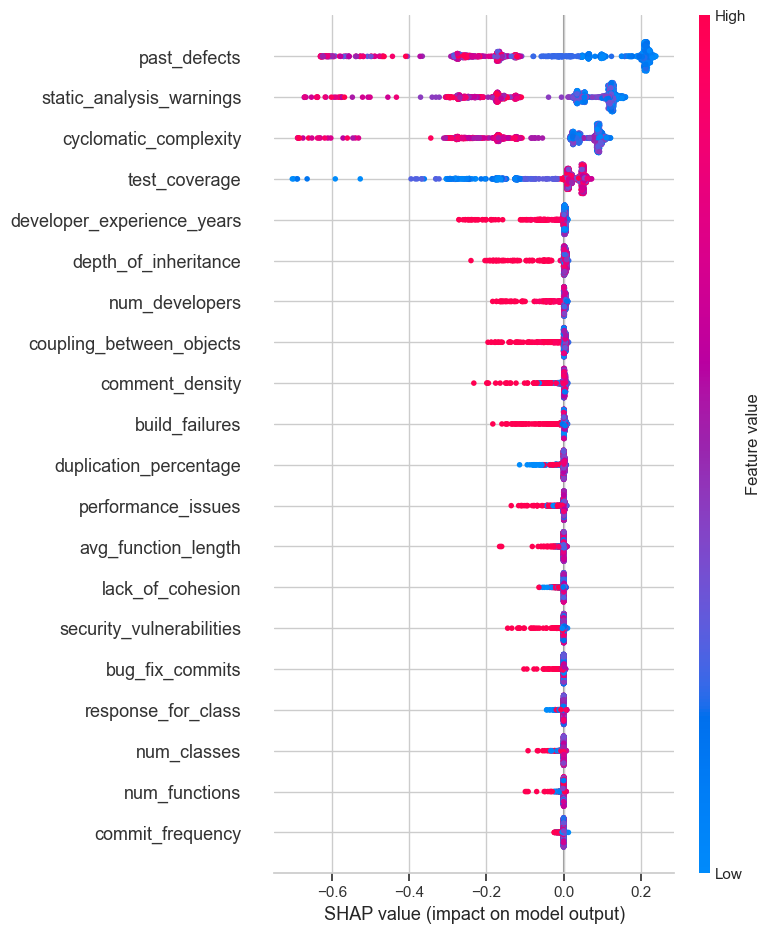

In [44]:
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
shap_matrix = np.array([sv[:, 0] for sv in shap_values])
shap.summary_plot(
    shap_matrix,
    X_test,
    feature_names=X_test.columns
)

In [45]:
shap_matrix_0 = np.array([sv[:, 0] for sv in shap_values])

shap_mean_0 = shap_matrix_0.mean(axis=0)

shap_df_0 = pd.DataFrame({
    "feature": X_test.columns,
    "mean_shap_0": shap_mean_0
}).sort_values(by="mean_shap_0", ascending=True)

shap_df_0

,feature,mean_shap_0
11,test_coverage,-0.012770
1,cyclomatic_complexity,-0.010465
6,developer_experience_years,-0.007360
7,num_developers,-0.004881
16,coupling_between_objects,-0.004736
14,depth_of_inheritance,-0.004336
4,comment_density,-0.004193
18,build_failures,-0.003532
12,duplication_percentage,-0.002990
21,performance_issues,-0.002632


# XGBoost

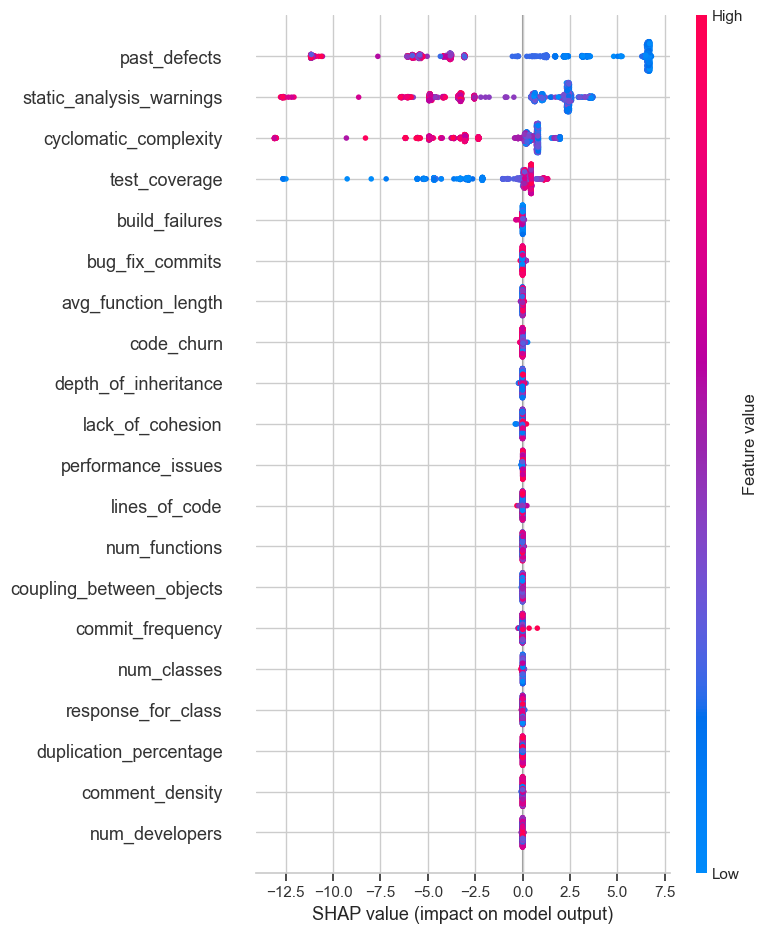

In [46]:
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(
    -shap_values,
    X_test,
    feature_names=X_test.columns
)

In [47]:
shap_mean_0 = -shap_values.mean(axis=0)

shap_df_0 = pd.DataFrame({
    "feature": X_test.columns,
    "mean_shap_0": shap_mean_0
}).sort_values(by="mean_shap_0", ascending=True)

shap_df_0

,feature,mean_shap_0
1,cyclomatic_complexity,-0.621988
11,test_coverage,-0.380241
19,static_analysis_warnings,-0.024254
18,build_failures,-0.011961
17,lack_of_cohesion,-0.005443
0,lines_of_code,-0.004644
14,depth_of_inheritance,-0.002987
16,coupling_between_objects,-0.001877
8,commit_frequency,-0.001720
9,bug_fix_commits,-0.001395


# Summary

In [48]:
models = {
    "RandomForest": rf_preds,
    "XGBoost": xgb_preds,
    "SVM_linear": svm_lin_preds,
    "SVM_rbf": svm_rbf_preds,
    "SVM_sigmoid": svm_sig_preds
}

results = []

for model_name, preds in models.items():
    results.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1_score": f1_score(y_test, preds)
    })

summary_df = pd.DataFrame(results)

summary_df = summary_df.sort_values(by="accuracy", ascending=False)

print(summary_df)

          model  accuracy  precision    recall  f1_score
1       XGBoost  0.997500   0.995025  1.000000  0.997506
0  RandomForest  0.977500   0.956938  1.000000  0.977995
2    SVM_linear  0.589167   0.577201  0.666667  0.618716
3       SVM_rbf  0.545833   0.529039  0.835000  0.647705
4   SVM_sigmoid  0.495000   0.496822  0.781667  0.607513
